# Linking PageXML regions and image thumbnails

This notebook demonstrates the two directions supported by `archival_structures.image`:

1. **PageXML → image**: draw the text regions of a PageXML `Scan` on its thumbnail image.
2. **image → PageXML**: select a region on the thumbnail, and add it back to the PageXML `Scan` as a new region.

The coordinate conversion between scan space (the PageXML document's own coordinate system,
matching the full-resolution scan) and thumbnail space (a smaller rendering of the same scan)
is handled by `Transform` (see `archival_structures.model.image`). The conversion between
PageXML `Coords` objects and this package's own `Box` objects is handled by
`archival_structures.image.pagexml_bridge`.

In [7]:
from pathlib import Path

from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.image.image_base import make_selection
from archival_structures.image.pagexml_bridge import (
    region_to_box, box_to_text_region, crop_box_from_image,
)
from archival_structures.model.image import Box

# this scan/thumbnail pair is part of the repo's example data
scan_xml = Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1/NL-AsnDA_0114.11_1_0004.xml')
thumb_path = Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1/thumb-width_300-scan-NL-AsnDA_0114.11_1_0004.jp2.png')

assert scan_xml.exists(), scan_xml
assert thumb_path.exists(), thumb_path

## Part 1: draw PageXML text regions on the thumbnail

Parse the PageXML file into a `PageXMLScan`, and build an `ImageSelection` for it: this is the
object that knows both the scan's pixel dimensions (from the PageXML `Coords`) and the
thumbnail's pixel dimensions (from the image file), and so can compute the `Transform` between
the two coordinate spaces (`image_sel.scan_to_thumb`).

In [8]:
scan = pagexml_parser.parse_pagexml_file(str(scan_xml))

# as_array=True so we can crop with numpy slicing later in Part 2; for drawing here we still
# work with a PIL copy of the same thumbnail
image_sel = make_selection(scan.coords.w, scan.coords.h, str(thumb_path), as_array=True)
thumb_image = Image.open(thumb_path).convert('RGB')

print(f"scan size:      {scan.coords.w} x {scan.coords.h}")
print(f"thumbnail size: {thumb_image.width} x {thumb_image.height}")
print(f"scan_to_thumb scale: {image_sel.scan_to_thumb.scale_x:.4f}, {image_sel.scan_to_thumb.scale_y:.4f}")

scan size:      4937 x 4009
thumbnail size: 300 x 243
scan_to_thumb scale: 0.0608, 0.0606


In [9]:
def draw_boxes(image: Image.Image, boxes: list[Box], outline="red", width=2) -> Image.Image:
    """Return a copy of `image` with `boxes` drawn on it as rectangles, labelled if `box.label` is set."""
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)
    for box in boxes:
        draw.rectangle([box.x, box.y, box.x + box.w, box.y + box.h], outline=outline, width=width)
        if box.label:
            draw.text((box.x + 2, box.y + 2), box.label, fill=outline)
    return annotated

r1: scan box {'x': 130, 'y': 257, 'w': 492, 'h': 1648} -> thumbnail box x=7.9, y=15.6, w=29.9, h=99.9
r2: scan box {'x': 622, 'y': 263, 'w': 1844, 'h': 3145} -> thumbnail box x=37.8, y=15.9, w=112.1, h=190.6
r3: scan box {'x': 2548, 'y': 2626, 'w': 18, 'h': 154} -> thumbnail box x=154.8, y=159.2, w=1.1, h=9.3
r4: scan box {'x': 2584, 'y': 3034, 'w': 20, 'h': 154} -> thumbnail box x=157.0, y=183.9, w=1.2, h=9.3
r5: scan box {'x': 2640, 'y': 1990, 'w': 56, 'h': 150} -> thumbnail box x=160.4, y=120.6, w=3.4, h=9.1
r6: scan box {'x': 2676, 'y': 654, 'w': 80, 'h': 159} -> thumbnail box x=162.6, y=39.6, w=4.9, h=9.6
r7: scan box {'x': 2692, 'y': 2554, 'w': 110, 'h': 209} -> thumbnail box x=163.6, y=154.8, w=6.7, h=12.7
r8: scan box {'x': 3028, 'y': 317, 'w': 1796, 'h': 3440} -> thumbnail box x=184.0, y=19.2, w=109.1, h=208.5


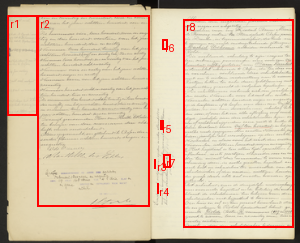

In [10]:
# `region_to_box` reads each PageXML text region's Coords (in scan space). `scan_to_thumb.apply`
# converts each box from scan space into thumbnail pixel space.
text_regions = scan.get_textual_regions()
thumb_boxes = [image_sel.scan_to_thumb.apply(region_to_box(region)) for region in text_regions]

for region, box in zip(text_regions, thumb_boxes):
    print(f"{region.id}: scan box {region.coords.box} -> thumbnail box "
          f"x={box.x:.1f}, y={box.y:.1f}, w={box.w:.1f}, h={box.h:.1f}")

draw_boxes(thumb_image, thumb_boxes)

As you can see, there is vertical text in the left margin of the page on the right-hand side that has not been properly recognised. 

## Part 2: select a region on the thumbnail, annotate it, write it back to the PageXML scan

In an interactive tool (e.g. `ThumbnailSelectionTagger` in `image_drawing.py`), the user would draw
a box directly on the thumbnail. Here we hard-code the box the user "drew", in thumbnail pixel
coordinates, to keep the notebook self-contained.

The created annotation box selects the region of the vertical text.

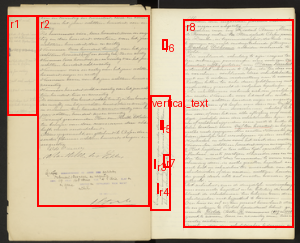

In [26]:
annotation_thumb_box = Box(150, 95, 20, 115, label='vertical_text')

draw_boxes(thumb_image, thumb_boxes + [annotation_thumb_box], outline="red")

Cropping the selected pixels (e.g. to inspect or save the annotated snippet) works directly in
thumbnail space with `crop_box_from_image`:

In [27]:
annotation_crop = crop_box_from_image(image_sel.thumbnail.image, annotation_thumb_box)
print(f"cropped pixel array shape: {annotation_crop.shape}")
Image.fromarray(annotation_crop)

cropped pixel array shape: (115, 20, 3)


To attach the annotation to the PageXML `Scan`, its coordinates need to be in scan space, not
thumbnail space. `image_sel.thumb_to_scan` is the inverse of `scan_to_thumb` from Part 1, so it
converts the other way:

In [28]:
annotation_scan_box = image_sel.thumb_to_scan.apply(annotation_thumb_box)
print(f"annotation in scan space: x={annotation_scan_box.x:.1f}, y={annotation_scan_box.y:.1f}, "
      f"w={annotation_scan_box.w:.1f}, h={annotation_scan_box.h:.1f}")

annotation in scan space: x=2468.5, y=1567.3, w=329.1, h=1897.3


In [29]:
# `box_to_text_region` builds a PageXMLTextRegion whose Coords are the (rectangular) bounding
# box of `annotation_scan_box`. `scan.add_child` attaches it to the scan, the same way pagexml-tools
# attaches any other region.
new_region = box_to_text_region(annotation_scan_box, doc_id=f"{scan.id}-manual-1")

print(f"text regions before: {len(scan.text_regions)}")
scan.add_child(new_region)
print(f"text regions after:  {len(scan.text_regions)}")
print(f"new region: id={new_region.id}, coords.box={new_region.coords.box}")

text regions before: 8
text regions after:  9
new region: id=NL-AsnDA_0114.11_1_0004.jpg-manual-1, coords.box={'x': 2468, 'y': 1567, 'w': 329, 'h': 1897}


The new region is now a regular part of the `Scan` object, alongside the regions that were
originally parsed from the PageXML file, and can be serialised back to PageXML XML using
pagexml-tools' own export functions.

### Verify the new region

Re-running the Part 1 drawing code now also picks up `manual-1`, confirming it really was
added to `scan.text_regions` rather than just existing as a standalone `Box`/`Coords`.

r1: scan box {'x': 130, 'y': 257, 'w': 492, 'h': 1648} -> thumbnail box x=7.9, y=15.6, w=29.9, h=99.9
r2: scan box {'x': 622, 'y': 263, 'w': 1844, 'h': 3145} -> thumbnail box x=37.8, y=15.9, w=112.1, h=190.6
NL-AsnDA_0114.11_1_0004.jpg-manual-1: scan box {'x': 2468, 'y': 1567, 'w': 329, 'h': 1897} -> thumbnail box x=150.0, y=95.0, w=20.0, h=115.0
r3: scan box {'x': 2548, 'y': 2626, 'w': 18, 'h': 154} -> thumbnail box x=154.8, y=159.2, w=1.1, h=9.3
r4: scan box {'x': 2584, 'y': 3034, 'w': 20, 'h': 154} -> thumbnail box x=157.0, y=183.9, w=1.2, h=9.3
r5: scan box {'x': 2640, 'y': 1990, 'w': 56, 'h': 150} -> thumbnail box x=160.4, y=120.6, w=3.4, h=9.1
r6: scan box {'x': 2676, 'y': 654, 'w': 80, 'h': 159} -> thumbnail box x=162.6, y=39.6, w=4.9, h=9.6
r7: scan box {'x': 2692, 'y': 2554, 'w': 110, 'h': 209} -> thumbnail box x=163.6, y=154.8, w=6.7, h=12.7
r8: scan box {'x': 3028, 'y': 317, 'w': 1796, 'h': 3440} -> thumbnail box x=184.0, y=19.2, w=109.1, h=208.5


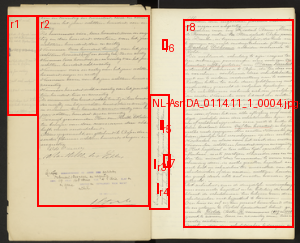

In [32]:
# `region_to_box` reads each PageXML text region's Coords (in scan space). `scan_to_thumb.apply`
# converts each box from scan space into thumbnail pixel space.
text_regions = scan.get_textual_regions()
thumb_boxes = [image_sel.scan_to_thumb.apply(region_to_box(region)) for region in text_regions]

for region, box in zip(text_regions, thumb_boxes):
    print(f"{region.id}: scan box {region.coords.box} -> thumbnail box "
          f"x={box.x:.1f}, y={box.y:.1f}, w={box.w:.1f}, h={box.h:.1f}")

draw_boxes(thumb_image, thumb_boxes)